In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib

In [2]:
data = pd.read_csv("./data/wine_train.csv")
data

,와인_종류,알코올_도수,사과산_함량,재_함량,재의_알칼리도,마그네슘_함량,총_페놀_함량,플라보노이드_함량,비플라보노이드_페놀_함량,프로안토시아닌_함량,색_강도,색조,희석_와인의_투과율_OD280_OD315,프롤린_함량
0,1,13.76,1.53,2.70,19.5,132,2.95,2.74,0.50,1.35,5.40,1.25,3.00,1235
1,2,12.67,0.98,2.24,18.0,99,2.20,1.94,0.30,1.46,2.62,1.23,3.16,450
2,1,13.58,1.66,2.36,19.1,106,2.86,3.19,0.22,1.95,6.90,1.09,2.88,1515
3,2,13.86,1.51,2.67,25.0,86,2.95,2.86,0.21,1.87,3.38,1.36,3.16,410
4,1,13.05,2.05,3.22,25.0,124,2.63,2.68,0.47,1.92,3.58,1.13,3.20,830
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101,2,12.43,1.53,2.29,21.5,86,2.74,3.15,0.39,1.77,3.94,0.69,2.84,352
102,3,12.20,3.03,2.32,19.0,96,1.25,0.49,0.40,0.73,5.50,0.66,1.83,510
103,1,13.51,1.80,2.65,19.0,110,2.35,2.53,0.29,1.54,4.20,1.10,2.87,1095
104,2,12.70,3.87,2.40,23.0,101,2.83,2.55,0.43,1.95,2.57,1.19,3.13,463


In [3]:
data['와인_종류'].value_counts()

와인_종류
2    42
1    35
3    29
Name: count, dtype: int64

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 106 entries, 0 to 105
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   와인_종류                   106 non-null    int64  
 1   알코올_도수                  106 non-null    float64
 2   사과산_함량                  106 non-null    float64
 3   재_함량                    106 non-null    float64
 4   재의_알칼리도                 106 non-null    float64
 5   마그네슘_함량                 106 non-null    int64  
 6   총_페놀_함량                 106 non-null    float64
 7   플라보노이드_함량               106 non-null    float64
 8   비플라보노이드_페놀_함량           106 non-null    float64
 9   프로안토시아닌_함량              106 non-null    float64
 10  색_강도                    106 non-null    float64
 11  색조                      106 non-null    float64
 12  희석_와인의_투과율_OD280_OD315  106 non-null    float64
 13  프롤린_함량                  106 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 11.

<Axes: >

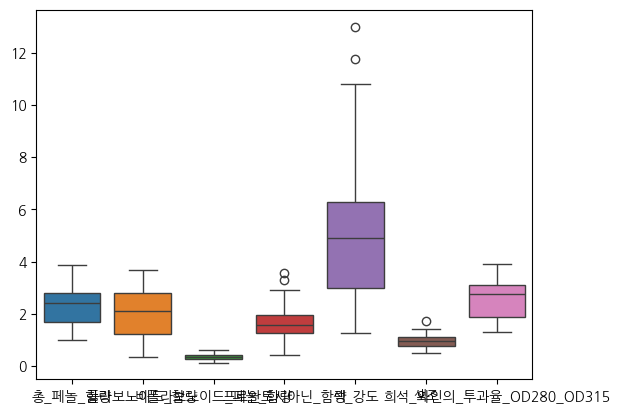

In [5]:
sns.boxplot(data.iloc[:,6:-1])

In [8]:
X = data.drop('와인_종류', axis=1)
y = data['와인_종류']

In [9]:
from sklearn.model_selection import train_test_split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

In [11]:
from sklearn.preprocessing import MinMaxScaler

In [13]:
mms = MinMaxScaler()
X_train_temp = mms.fit_transform(X_train)
X_test_temp = mms.transform(X_test)
mms_X_train = pd.DataFrame(X_train_temp, columns=X_train.columns, index=X_train.index)
mms_X_test = pd.DataFrame(X_test_temp, columns=X_test.columns, index=X_test.index)

In [14]:
mms_X_train

,알코올_도수,사과산_함량,재_함량,재의_알칼리도,마그네슘_함량,총_페놀_함량,플라보노이드_함량,비플라보노이드_페놀_함량,프로안토시아닌_함량,색_강도,색조,희석_와인의_투과율_OD280_OD315,프롤린_함량
79,0.700000,0.479508,0.634409,0.573171,0.294872,0.223077,0.021875,0.74,0.132867,0.392491,0.390244,0.189189,0.324980
54,0.297368,0.141393,0.510753,0.743902,0.076923,0.203846,0.375000,0.60,0.398601,0.099829,0.691057,0.359073,0.175424
98,0.755263,0.155738,0.408602,0.329268,0.217949,0.711538,0.906250,0.16,0.601399,0.411263,0.349593,0.772201,0.571544
20,0.207895,0.163934,0.279570,0.542683,0.025641,0.480769,0.359375,0.48,0.349650,0.066553,0.373984,0.428571,0.110752
92,0.823684,0.325820,0.602151,0.573171,0.089744,0.165385,0.065625,0.62,0.286713,0.718430,0.113821,0.146718,0.308812
...,...,...,...,...,...,...,...,...,...,...,...,...,...
43,0.744737,0.088115,0.489247,0.329268,0.179487,0.665385,0.831250,0.18,0.500000,0.506826,0.430894,0.857143,0.620049
16,0.413158,0.086066,0.290323,0.481707,0.051282,0.076923,0.271875,0.32,0.325175,0.099829,0.455285,0.555985,0.229588
59,0.484211,0.756148,0.602151,0.664634,0.025641,0.173077,0.050000,0.68,0.153846,0.543515,0.048780,0.204633,0.280517
37,0.000000,0.120902,0.451613,0.664634,0.012821,0.465385,0.525000,0.78,0.555944,0.052901,1.000000,0.594595,0.104285


In [16]:
y_train = pd.get_dummies(y_train)
y_train

,1,2,3
79,False,False,True
54,False,True,False
98,True,False,False
20,False,True,False
92,False,False,True
...,...,...,...
43,True,False,False
16,False,True,False
59,False,False,True
37,False,True,False


In [17]:
y_test = pd.get_dummies(y_test)
y_test

,1,2,3
61,False,False,True
63,False,True,False
3,False,True,False
40,False,True,False
97,False,False,True
81,False,False,True
78,False,False,True
95,False,True,False
65,False,False,True
57,True,False,False


In [18]:
from keras.models import Sequential
from keras.layers import Input, Dense, Dropout
from keras.callbacks import EarlyStopping, ModelCheckpoint

In [19]:
model = Sequential()
model.add(Input(shape=(X_train.shape[1],)))
model.add(Dense(32, activation='relu'))
model.add(Dense(16, activation='relu'))
model.add(Dense(8, activation='relu'))
model.add(Dense(y_train.shape[1], activation='softmax'))
model.summary()

I0000 00:00:1747292888.152615  202271 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3586 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,139 (4.45 KB)

 Trainable params: 1,139 (4.45 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/1000


I0000 00:00:1747293187.203889  202383 service.cc:152] XLA service 0x7f195c00b830 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1747293187.203928  202383 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 3060 Laptop GPU, Compute Capability 8.6
2025-05-15 16:13:07.240884: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1747293187.404854  202383 cuda_dnn.cc:529] Loaded cuDNN version 90300


1/5 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 0.1250 - loss: 1.1084

I0000 00:00:1747293188.473120  202383 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 372ms/step - accuracy: 0.2104 - loss: 1.1082 - val_accuracy: 0.3438 - val_loss: 1.0964
Epoch 2/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.3766 - loss: 1.0959 - val_accuracy: 0.5312 - val_loss: 1.0909
Epoch 3/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.4434 - loss: 1.0909 - val_accuracy: 0.4688 - val_loss: 1.0850
Epoch 4/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.5568 - loss: 1.0821 - val_accuracy: 0.4688 - val_loss: 1.0792
Epoch 5/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.5028 - loss: 1.0722 - val_accuracy: 0.5312 - val_loss: 1.0711
Epoch 6/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.5048 - loss: 1.0659 - val_accuracy: 0.5625 - val_loss: 1.0628
Epoch 7/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.5800 - loss: 1.0536 - val_accuracy: 0.6250 - val_loss: 1.0547
Epoch 8/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.6922 - loss: 1.0373 - val_accuracy: 0.5938 - val_loss: 1.0

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9738 - loss: 0.2051 - val_accuracy: 0.9688 - val_loss: 0.2633
Epoch 52/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9929 - loss: 0.1540 - val_accuracy: 0.9688 - val_loss: 0.2545
Epoch 53/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9929 - loss: 0.1491 - val_accuracy: 0.9375 - val_loss: 0.2466
Epoch 54/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.9955 - loss: 0.1392 - val_accuracy: 0.9375 - val_loss: 0.2372
Epoch 55/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.9842 - loss: 0.1449 - val_accuracy: 0.9375 - val_loss: 0.2333
Epoch 56/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.9842 - loss: 0.1417 - val_accuracy: 0.9688 - val_loss: 0.2223
Epoch 57/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.9738 - loss: 0.1456 - val_accuracy: 0.9688 - val_loss: 0.2153
Epoch 58/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.9894 - loss: 0.1096 - val_accuracy: 0.9688 - val_los

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 1.0000 - loss: 0.0283 - val_accuracy: 0.9688 - val_loss: 0.1404
Epoch 102/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 1.0000 - loss: 0.0290 - val_accuracy: 0.9688 - val_loss: 0.1397
Epoch 103/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 1.0000 - loss: 0.0275 - val_accuracy: 0.9688 - val_loss: 0.1432
Epoch 104/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 1.0000 - loss: 0.0254 - val_accuracy: 0.9688 - val_loss: 0.1387
Epoch 105/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 1.0000 - loss: 0.0193 - val_accuracy: 0.9688 - val_loss: 0.1376
Epoch 106/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 1.0000 - loss: 0.0220 - val_accuracy: 0.9688 - val_loss: 0.1366
Epoch 107/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 1.0000 - loss: 0.0211 - val_accuracy: 0.9688 - val_loss: 0.1357
Epoch 108/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 1.0000 - loss: 0.0191 - val_accuracy: 0.9688 - 

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 1.0000 - loss: 0.0086 - val_accuracy: 0.9688 - val_loss: 0.1262
Epoch 152/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 1.0000 - loss: 0.0093 - val_accuracy: 0.9688 - val_loss: 0.1295
Epoch 153/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 1.0000 - loss: 0.0089 - val_accuracy: 0.9688 - val_loss: 0.1277
Epoch 154/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 1.0000 - loss: 0.0078 - val_accuracy: 0.9688 - val_loss: 0.1253
Epoch 155/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 1.0000 - loss: 0.0065 - val_accuracy: 0.9688 - val_loss: 0.1257
Epoch 156/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 1.0000 - loss: 0.0099 - val_accuracy: 0.9688 - val_loss: 0.1249
Epoch 157/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 1.0000 - loss: 0.0076 - val_accuracy: 0.9688 - val_loss: 0.1254
Epoch 158/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 1.0000 - loss: 0.0080 - val_accuracy: 0.9688 - 

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 1.0000 - loss: 0.0037 - val_accuracy: 0.9688 - val_loss: 0.1279
Epoch 202/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 1.0000 - loss: 0.0041 - val_accuracy: 0.9688 - val_loss: 0.1280
Epoch 203/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 1.0000 - loss: 0.0029 - val_accuracy: 0.9688 - val_loss: 0.1288
Epoch 204/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 1.0000 - loss: 0.0034 - val_accuracy: 0.9688 - val_loss: 0.1285
Epoch 205/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 1.0000 - loss: 0.0031 - val_accuracy: 0.9688 - val_loss: 0.1271
Epoch 206/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 1.0000 - loss: 0.0032 - val_accuracy: 0.9688 - val_loss: 0.1265
Epoch 207/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 1.0000 - loss: 0.0039 - val_accuracy: 0.9688 - val_loss: 0.1287
Epoch 208/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 1.0000 - loss: 0.0034 - val_accuracy: 0.9688 - 

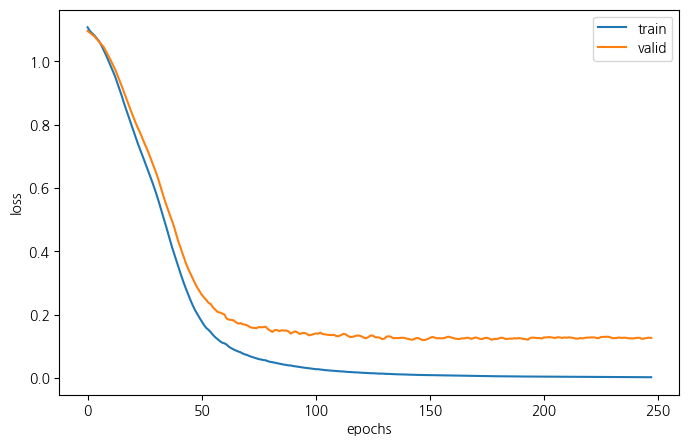

In [20]:
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
early_stop = EarlyStopping(patience=100)
file_path = "./model/wine_loss{val_loss:.4f}_epoch_{epoch:04d}.keras"
model_save= ModelCheckpoint(filepath=file_path, save_best_only=True)
history = model.fit(mms_X_train, y_train,
                   epochs=1000,
                   batch_size=16,
                   validation_data=(mms_X_test, y_test),
                   callbacks=[early_stop, model_save])
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel("epochs")
plt.ylabel("loss")
plt.legend(['train', 'valid'])
plt.show()

In [21]:
from keras.models import load_model

In [22]:
best_model = load_model("./model/wine_loss0.1195_epoch_0148.keras")
pred2 = best_model.evaluate(mms_X_test, y_test)
print("loss: ", pred2[0], "accuracy: ", pred2[1])

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 650ms/step - accuracy: 0.9688 - loss: 0.1195
loss:  0.11945375800132751 accuracy:  0.96875
